# Importing modules and settings

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
from matplotlib.pyplot import rc_context

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

General settings of Scanpy

In [5]:
sc.settings.verbosity = 3 
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.21.5 scipy==1.7.3 pandas==1.4.2 scikit-learn==1.0.2 statsmodels==0.13.2 python-igraph==0.9.11 pynndescent==0.5.7


In [6]:
umap_cmap = sns.blend_palette(['xkcd:light grey', 'xkcd:indigo'], as_cmap = True)

# Declaring the input and output files

In [7]:
adata = sc.read_h5ad('./Serotonergic_data_preprocessed.h5ad')

In [8]:
adata

AnnData object with n_obs × n_vars = 47292 × 24000
    obs: 'sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio', 'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4'
    var: 'gene_ids', 'feature_types', 'longest_isoform', 'gene_type', 'gene_JakkeGuo', 'gene_Jakke_ver1', 'gene_ddv6', 'jakkeguo_collapsed', 'jakke_ver1_collapsed', 'ddv6_collapsed', 'Preferred_name', 'Description', 'PFAMs', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'biological_replicates', 'dendrogram_leiden_1', 'dendrogram_leiden_2', 'dendrogram_leiden_3', 'dendrogram_leiden_4', 'hvg', 'leiden', 'leiden_1_colors', 'leiden_2_colors', 'leiden_3_colors', 'leiden_4_colors', 'library_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups_logreg_leiden_1', '

In [9]:
leiden_names = adata.obs.columns[adata.obs.columns.str.contains('leiden')].to_list()

In [10]:
leiden_names

['leiden_1', 'leiden_2', 'leiden_3', 'leiden_4']

In [11]:
adata.var

,gene_ids,feature_types,longest_isoform,gene_type,gene_JakkeGuo,gene_Jakke_ver1,gene_ddv6,jakkeguo_collapsed,jakke_ver1_collapsed,ddv6_collapsed,...,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
h1SMcG0000008,h1SMcG0000008,Gene Expression,h1SMcT0000008.1,hconf,SMEST029651001.1,SMEST029651001.1,dd_Smed_v6_35379_0_1,"SMEST029651001.1,SMEST029651002.1,SmMSTRG.9911...","SMEST029651001.1,SMEST029651002.1",dd_Smed_v6_35379_0_1,...,10,0.000232,99.978886,11.0,True,0.000284,0.477953,1.455614,0.000172,0.012502
h1SMcG0000009,h1SMcG0000009,Gene Expression,h1SMcT0000009.2,hconf,SMEST029652002.1,SMEST029652002.1,dd_Smed_v6_5323_0_1,"SMEST029652002.1,SmMSTRG.9914.2,SmMSTRG.9914.3...",SMEST029652002.1,dd_Smed_v6_5323_0_1,...,196,0.004159,99.586175,197.0,True,0.003342,0.036366,0.147434,0.002345,0.039136
h1SMcG0000011,h1SMcG0000011,Gene Expression,h1SMcT0000011.1,hconf,SMEST029655001.1,SMEST029655001.1,dd_Smed_v6_6416_0_1,"SMEST029655001.1,SMEST029655002.1,SmMSTRG.9916...","SMEST029655001.1,SMEST029655002.1",dd_Smed_v6_6416_0_1,...,2366,0.053312,95.004539,2525.0,True,0.044958,0.140558,0.456098,0.031060,0.146029
h1SMcG0000012,h1SMcG0000012,Gene Expression,h1SMcT0000012.1,hconf,SmMSTRG.9913.2,SMEST029666001.1,dd_Smed_v6_20296_0_1,"SMEST029666001.1,SmMSTRG.9913.2",SMEST029666001.1,dd_Smed_v6_20296_0_1,...,25,0.000549,99.947216,26.0,True,0.000470,0.185634,0.589633,0.000318,0.015024
h1SMcG0000013,h1SMcG0000013,Gene Expression,h1SMcT0000013.5,hconf,SmMSTRG.9917.1,MSTRG.9917.1,dd_Smed_v6_4708_0_1,"SMEST029667004.1,SmMSTRG.9917.1,SmMSTRG.9917.2...","MSTRG.9917.1,SMEST029667004.1",dd_Smed_v6_4708_0_1,...,681,0.014885,98.562169,705.0,True,0.012562,0.100089,0.336211,0.008670,0.077038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
h1SMnG0034970,h1SMnG0034970,Gene Expression,h1SMnT0034970.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000040,0.120145,0.395626,0.000027,0.004380
h1SMnG0035064,h1SMnG0035064,Gene Expression,h1SMnT0035064.1,other,-,-,-,-,-,-,...,1,0.000021,99.997889,1.0,True,0.000026,0.225550,0.707884,0.000017,0.003735
h1SMnG0035227,h1SMnG0035227,Gene Expression,h1SMnT0035227.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000049,0.321466,0.992030,0.000031,0.005060
h1SMnG0035258,h1SMnG0035258,Gene Expression,h1SMnT0035258.1,hconf,-,-,-,-,-,-,...,3,0.000063,99.993666,3.0,True,0.000092,0.375602,1.152403,0.000057,0.007119


In [12]:
adata.obs.columns


Index(['sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio',
       'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4'],
      dtype='object')

# Selecting one clustering layer from leiden_names

In [13]:
clusteringlayer = 'leiden_3'

# Pandas dataframe with markers and excel file

In [14]:
list(adata.uns)

['biological_replicates',
 'dendrogram_leiden_1',
 'dendrogram_leiden_2',
 'dendrogram_leiden_3',
 'dendrogram_leiden_4',
 'hvg',
 'leiden',
 'leiden_1_colors',
 'leiden_2_colors',
 'leiden_3_colors',
 'leiden_4_colors',
 'library_colors',
 'log1p',
 'neighbors',
 'pca',
 'rank_genes_groups_logreg_leiden_1',
 'rank_genes_groups_logreg_leiden_2',
 'rank_genes_groups_logreg_leiden_3',
 'rank_genes_groups_logreg_leiden_4',
 'rank_genes_groups_wilcox_leiden_1',
 'rank_genes_groups_wilcox_leiden_2',
 'rank_genes_groups_wilcox_leiden_3',
 'rank_genes_groups_wilcox_leiden_4',
 'sample_colors',
 'samples',
 'technical_replicates',
 'umap']

In [15]:
markers_w = pd.DataFrame(adata.uns['rank_genes_groups_wilcox_'+clusteringlayer]['names']).head(50)

In [16]:
markers_w

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,h1SMcG0008035,h1SMcG0019136,h1SMcG0014354,h1SMcG0000998,h1SMcG0012529,h1SMcG0008035,h1SMcG0016328,h1SMcG0017400,h1SMcG0013410,h1SMcG0005535,...,h1SMcG0019666,h1SMnG0003451,h1SMcG0022476,h1SMnG0016136,h1SMcG0008035,h1SMcG0011185,h1SMcG0008035,h1SMnG0029694,h1SMcG0015124,h1SMnG0015037
1,h1SMnG0035608,h1SMcG0020223,h1SMcG0015236,h1SMcG0014354,h1SMcG0000479,h1SMnG0035616,h1SMcG0017400,h1SMcG0009632,h1SMcG0008281,h1SMcG0005534,...,h1SMcG0007949,h1SMnG0003440,h1SMcG0008035,h1SMnG0032454,h1SMnG0035608,h1SMcG0004553,h1SMnG0006389,h1SMnG0022994,h1SMcG0021687,h1SMnG0015038
2,h1SMcG0007496,h1SMcG0015883,h1SMcG0022555,h1SMcG0006857,h1SMnG0035616,h1SMcG0007496,h1SMcG0016327,h1SMcG0003474,h1SMnG0022131,h1SMnG0035616,...,h1SMcG0019473,h1SMnG0003447,h1SMnG0034729,h1SMnG0031486,h1SMnG0035616,h1SMcG0008035,h1SMcG0001184,h1SMnG0028272,h1SMcG0021199,h1SMnG0032262
3,h1SMcG0013999,h1SMcG0019758,h1SMcG0000998,h1SMcG0007433,h1SMcG0009632,h1SMnG0035608,h1SMcG0009175,h1SMcG0009633,h1SMcG0013407,h1SMcG0012505,...,h1SMcG0009945,h1SMnG0003450,h1SMnG0035616,h1SMcG0007441,h1SMcG0007496,h1SMcG0010823,h1SMnG0035138,h1SMnG0006977,h1SMnG0012122,h1SMnG0015048
4,h1SMcG0010823,h1SMcG0009890,h1SMcG0016741,h1SMcG0022555,h1SMcG0009633,h1SMcG0010823,h1SMcG0003473,h1SMcG0016327,h1SMcG0002559,h1SMnG0035608,...,h1SMcG0006051,h1SMcG0002459,h1SMcG0022475,h1SMcG0019136,h1SMcG0006230,h1SMcG0008694,h1SMcG0012486,h1SMcG0020223,h1SMcG0013245,h1SMcG0020223
5,h1SMcG0019482,h1SMcG0009596,h1SMcG0001082,h1SMcG0020983,h1SMcG0007496,h1SMcG0012505,h1SMcG0003471,h1SMcG0008074,h1SMcG0009480,h1SMcG0005543,...,h1SMcG0004268,h1SMnG0003448,h1SMcG0010823,h1SMcG0015883,h1SMcG0017264,h1SMnG0035608,h1SMcG0013999,h1SMcG0020983,h1SMcG0005273,h1SMcG0019136
6,h1SMcG0012505,h1SMnG0006366,h1SMcG0007433,h1SMcG0016741,h1SMcG0011829,h1SMcG0010835,h1SMnG0002083,h1SMnG0009126,h1SMnG0021984,h1SMcG0010823,...,h1SMcG0015598,h1SMnG0011942,h1SMcG0007496,h1SMcG0022127,h1SMcG0019482,h1SMcG0007496,h1SMcG0021685,h1SMcG0014354,h1SMcG0016292,h1SMcG0019758
7,h1SMcG0010835,h1SMcG0013355,h1SMcG0006857,h1SMcG0009472,h1SMnG0017210,h1SMcG0019482,h1SMcG0020223,h1SMcG0001608,h1SMnG0022132,h1SMcG0005567,...,h1SMcG0010035,h1SMnG0003940,h1SMcG0021319,h1SMcG0020223,h1SMcG0013540,h1SMcG0010835,h1SMcG0018011,h1SMnG0029503,h1SMcG0004811,h1SMcG0000462
8,h1SMnG0035616,h1SMcG0005152,h1SMcG0006787,h1SMcG0006787,h1SMcG0008011,h1SMcG0013999,h1SMnG0009126,h1SMcG0016328,h1SMcG0009479,h1SMnG0035175,...,h1SMcG0019080,h1SMcG0022433,h1SMnG0035608,h1SMcG0022380,h1SMnG0000878,h1SMnG0019652,h1SMcG0017355,h1SMcG0019136,h1SMcG0021885,h1SMcG0012368
9,h1SMcG0005241,h1SMcG0003247,h1SMcG0014134,h1SMcG0001082,h1SMcG0002269,h1SMcG0002117,h1SMcG0013759,h1SMcG0003471,h1SMcG0021445,h1SMcG0005613,...,h1SMcG0019851,h1SMcG0018192,h1SMcG0010835,h1SMcG0011017,h1SMcG0012505,h1SMcG0010238,h1SMcG0013540,h1SMcG0010774,h1SMcG0008444,h1SMcG0013018


In [17]:
markers_w_l = pd.DataFrame(adata.uns['rank_genes_groups_wilcox_'+clusteringlayer]['pvals_adj']).head(50)

In [18]:
markers_l = pd.DataFrame(adata.uns['rank_genes_groups_logreg_'+clusteringlayer]['names']).head(50)

In [19]:
markers_l

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,h1SMcG0008035,h1SMcG0004048,h1SMcG0016673,h1SMcG0000998,h1SMcG0000479,h1SMcG0008035,h1SMcG0017400,h1SMcG0017400,h1SMcG0013410,h1SMcG0005535,...,h1SMcG0019666,h1SMnG0003447,h1SMnG0034729,h1SMnG0016136,h1SMnG0000878,h1SMcG0011185,h1SMnG0006389,h1SMnG0029694,h1SMcG0015124,h1SMnG0015048
1,h1SMnG0007188,h1SMcG0007378,h1SMcG0020022,h1SMcG0006857,h1SMcG0012529,h1SMnG0035616,h1SMcG0009175,h1SMcG0003474,h1SMnG0022131,h1SMcG0005534,...,h1SMcG0007949,h1SMnG0003451,h1SMcG0022476,h1SMnG0032454,h1SMnG0006413,h1SMcG0004553,h1SMcG0008035,h1SMnG0022994,h1SMcG0021687,h1SMnG0032262
2,h1SMcG0009165,h1SMcG0003346,h1SMcG0015236,h1SMcG0001827,h1SMcG0011728,h1SMcG0008755,h1SMcG0005487,h1SMcG0007991,h1SMcG0008281,h1SMcG0005567,...,h1SMcG0006051,h1SMnG0003440,h1SMcG0022475,h1SMnG0031486,h1SMcG0008035,h1SMcG0008694,h1SMcG0021685,h1SMnG0028272,h1SMcG0021199,h1SMnG0015037
3,h1SMnG0014807,h1SMcG0015883,h1SMcG0017034,h1SMcG0014406,h1SMcG0008011,h1SMcG0013921,h1SMcG0016328,h1SMcG0003229,h1SMcG0009480,h1SMcG0003194,...,h1SMcG0009945,h1SMnG0003450,h1SMcG0022474,h1SMcG0007441,h1SMcG0022255,h1SMcG0012023,h1SMcG0018285,h1SMcG0020983,h1SMnG0012122,h1SMnG0015038
4,h1SMcG0005241,h1SMcG0002345,h1SMcG0000998,h1SMcG0015903,h1SMcG0010557,h1SMcG0017814,h1SMcG0003473,h1SMcG0011716,h1SMcG0009479,h1SMcG0005543,...,h1SMcG0019473,h1SMnG0003448,h1SMcG0021319,h1SMcG0015883,h1SMcG0017264,h1SMnG0019652,h1SMcG0001184,h1SMcG0014354,h1SMcG0013245,h1SMcG0020223
5,h1SMcG0013999,h1SMcG0015241,h1SMcG0003207,h1SMcG0007433,h1SMcG0011829,h1SMcG0008382,h1SMcG0004437,h1SMcG0008073,h1SMcG0002559,h1SMcG0005539,...,h1SMcG0019080,h1SMcG0002459,h1SMcG0004811,h1SMcG0022127,h1SMcG0009670,h1SMcG0010238,h1SMcG0005103,h1SMnG0026663,h1SMcG0013410,h1SMcG0019136
6,h1SMcG0016288,h1SMcG0000432,h1SMcG0016202,h1SMcG0020983,h1SMcG0009465,h1SMcG0019383,h1SMnG0009126,h1SMcG0005694,h1SMnG0022132,h1SMcG0011666,...,h1SMcG0015598,h1SMnG0011942,h1SMcG0001110,h1SMcG0022380,h1SMcG0003751,h1SMcG0008470,h1SMnG0035138,h1SMnG0005858,h1SMcG0005273,h1SMcG0000462
7,h1SMcG0016303,h1SMnG0006366,h1SMcG0021771,h1SMcG0004724,h1SMcG0009632,h1SMnG0024805,h1SMcG0003471,h1SMnG0009126,h1SMcG0002557,h1SMcG0005613,...,h1SMcG0019851,h1SMnG0003940,h1SMnG0034590,h1SMcG0011017,h1SMcG0009496,h1SMnG0030748,h1SMnG0022567,h1SMcG0016344,h1SMcG0020223,h1SMcG0013018
8,h1SMcG0007581,h1SMcG0009545,h1SMcG0010878,h1SMcG0014354,h1SMcG0011828,h1SMcG0016136,h1SMcG0013759,h1SMcG0001776,h1SMcG0016889,h1SMcG0016202,...,h1SMcG0010035,h1SMcG0018192,h1SMcG0021533,h1SMcG0016691,h1SMcG0004404,h1SMcG0001078,h1SMcG0017355,h1SMcG0019136,h1SMcG0009479,h1SMcG0019758
9,h1SMcG0006263,h1SMcG0001467,h1SMcG0017506,h1SMcG0002895,h1SMcG0022252,h1SMcG0003552,h1SMcG0007170,h1SMcG0000747,h1SMcG0003101,h1SMcG0008441,...,h1SMcG0004268,h1SMnG0003941,h1SMcG0008035,h1SMcG0004357,h1SMcG0020812,h1SMcG0017176,h1SMcG0012501,h1SMcG0009472,h1SMcG0008444,h1SMcG0012368


In [20]:
with pd.ExcelWriter('./outputs/'+clusteringlayer+'_markers_wilcoxon.xlsx') as writer:
    for col in markers_w.columns:
        df = adata.raw.var.loc[markers_w[col][markers_w_l[col] < 0.05].to_list()][['gene_type','gene_ddv6', 'Preferred_name','Description']]
        df.to_excel(writer, sheet_name='Cluster '+ col)

In [21]:
with pd.ExcelWriter('./outputs/'+clusteringlayer+'_markers_logreg.xlsx') as writer:
    for col in markers_w.columns:
        df = adata.raw.var.loc[markers_l['50'].to_list()][['gene_type','gene_ddv6', 'Preferred_name','Description']]
        df.to_excel(writer, sheet_name='Cluster '+ col)

# Plots markers

In [22]:
def get_plots (clusteringlayer, cluster, li_markers):
    fig, axs = plt.subplots(3, 3, figsize = (15, 15))
    
    sc.pl.umap(adata, color= clusteringlayer, legend_loc = 'on data', groups = cluster, na_in_legend = False, size = 5, legend_fontsize = 7, title = clusteringlayer+' cluster '+cluster, show = False, ax = axs[0, 0])
    
    while len(li_markers) < 8:
        li_markers.append(None)

    gene01 = li_markers[0]
    gene02 = li_markers[1]
    gene10 = li_markers[2]
    gene11 = li_markers[3]
    gene12 = li_markers[4]
    gene20 = li_markers[5]
    gene21 = li_markers[6]
    gene22 = li_markers[7]


    #Row 0 first row
    sc.pl.umap(adata, color= gene01, title = gene01, color_map = umap_cmap, show = False, ax = axs[0, 1])
    sc.pl.umap(adata, color= gene02, title = gene02, color_map = umap_cmap, show = False, ax = axs[0, 2])
    

    #Row 1 second row
    
    sc.pl.umap(adata, color= gene10, title = gene10, color_map = umap_cmap, show = False, ax = axs[1, 0])
    sc.pl.umap(adata, color= gene11, title = gene11, color_map = umap_cmap, show = False, ax = axs[1, 1])
    sc.pl.umap(adata, color= gene12, title = gene12, color_map = umap_cmap, show = False, ax = axs[1, 2])
    

    #Row 2 third row
    
    sc.pl.umap(adata, color= gene20, title = gene20, color_map = umap_cmap, show = False, ax = axs[2, 0])
    sc.pl.umap(adata, color= gene21, title = gene21, color_map = umap_cmap, show = False, ax = axs[2, 1])
    sc.pl.umap(adata, color= gene22, title = gene22, color_map = umap_cmap, show = False, ax = axs[2, 2])
    #new_fig = fig
    #plt.close(fig)
    #fig.clf()
    return fig
    plt.close(fig)

In [23]:
for i in adata.obs[clusteringlayer].cat.categories:
    li = []
    lfc_s = pd.Series(adata.uns['rank_genes_groups_wilcox_'+clusteringlayer]['logfoldchanges'][i])
    pval_s = pd.Series(adata.uns['rank_genes_groups_wilcox_'+clusteringlayer]['pvals'][i])
    he_m = max(list(set(pval_s[pval_s < 0.05].index.to_list()) & set(lfc_s[lfc_s > 0].index.to_list())))
    wl = pd.DataFrame(adata.uns['rank_genes_groups_wilcox_'+clusteringlayer]['names']).head(he_m)[i]
    lr = pd.DataFrame(adata.uns['rank_genes_groups_logreg_'+clusteringlayer]['names']).head(30)[i]
    li = wl[wl.isin(lr)].to_list()
    figure = get_plots(clusteringlayer, i, li)
    figure.savefig('./outputs/markers/'+ clusteringlayer+'_cluster_'+i+'.pdf',format = 'pdf')
    #change directory
    figure.clf()
    plt.close(figure)

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is d

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is d

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is d

# Extracting counts per cluster and sample

In [24]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,130,148.0,0.0,0.0,8,9,7,25
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,159,176.0,0.0,0.0,1,1,1,0
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,359,502.0,0.0,0.0,0,0,0,7
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,149,185.0,0.0,0.0,4,3,9,5
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,166,180.0,0.0,0.0,2,6,3,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,212,411.0,0.0,0.0,7,37,26,49
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,186,262.0,0.0,0.0,0,0,5,4
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,103,110.0,0.0,0.0,5,8,6,3
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,201,238.0,0.0,0.0,1,1,1,0


In [25]:
counts_di = {}
for leiden_i in leiden_names:
    series = []
    total = adata.obs[leiden_i].value_counts().rename(leiden_i + '_' + 'total')
    series.append(total)
    for sample_bio in adata.obs['sample_bio'].cat.categories:
        partial = adata.obs[adata.obs['sample_bio'] == sample_bio][leiden_i].value_counts().rename(leiden_i + '_' + sample_bio)
        series.append(partial)
    counts_di[leiden_i] = pd.concat(series, axis = 1)
    

In [26]:
for key in counts_di.keys():
    counts_di[key].to_excel('outputs/csv_counts/' + key + '.xlsx')

In [27]:
counts_di2 = {}
for leiden_i in leiden_names:
    series = []
    total = adata.obs[leiden_i].value_counts().rename(leiden_i + '_' + 'total')
    series.append(total)
    for sample in adata.obs['sample'].cat.categories:
        partial = adata.obs[adata.obs['sample'] == sample][leiden_i].value_counts().rename(leiden_i + '_' + sample)
        series.append(partial)
    counts_di2[leiden_i] = pd.concat(series, axis = 1)
    

In [28]:
counts_df = counts_di2[clusteringlayer]

In [29]:
counts_df

,leiden_3_total,leiden_3_gfp(RNAi),leiden_3_lhx1/5-1(RNAi),leiden_3_pitx(RNAi)
0,3468,1285,1037,1146
1,3335,1132,1154,1049
2,2410,775,819,816
3,2404,875,766,763
4,2384,899,696,789
...,...,...,...,...
69,22,5,10,7
70,22,8,4,10
71,21,6,9,6
72,17,9,1,7


In [30]:
totals = counts_df.sum(axis = 0)

In [31]:
totals

leiden_3_total             47292
leiden_3_gfp(RNAi)         16739
leiden_3_lhx1/5-1(RNAi)    15237
leiden_3_pitx(RNAi)        15316
dtype: int64

In [32]:
percs_df = counts_df / totals * 100

In [33]:
percs_df

,leiden_3_total,leiden_3_gfp(RNAi),leiden_3_lhx1/5-1(RNAi),leiden_3_pitx(RNAi)
0,7.333164,7.676683,6.805802,7.482371
1,7.051933,6.762650,7.573669,6.849047
2,5.095999,4.629906,5.375074,5.327762
3,5.083312,5.227313,5.027236,4.981718
4,5.041022,5.370691,4.567828,5.151476
...,...,...,...,...
69,0.046519,0.029870,0.065630,0.045704
70,0.046519,0.047793,0.026252,0.065291
71,0.044405,0.035844,0.059067,0.039175
72,0.035947,0.053767,0.006563,0.045704


In [34]:
percs_df.drop('leiden_3_total', axis=1, inplace=True)

In [35]:
percs_df

,leiden_3_gfp(RNAi),leiden_3_lhx1/5-1(RNAi),leiden_3_pitx(RNAi)
0,7.676683,6.805802,7.482371
1,6.762650,7.573669,6.849047
2,4.629906,5.375074,5.327762
3,5.227313,5.027236,4.981718
4,5.370691,4.567828,5.151476
...,...,...,...
69,0.029870,0.065630,0.045704
70,0.047793,0.026252,0.065291
71,0.035844,0.059067,0.039175
72,0.053767,0.006563,0.045704


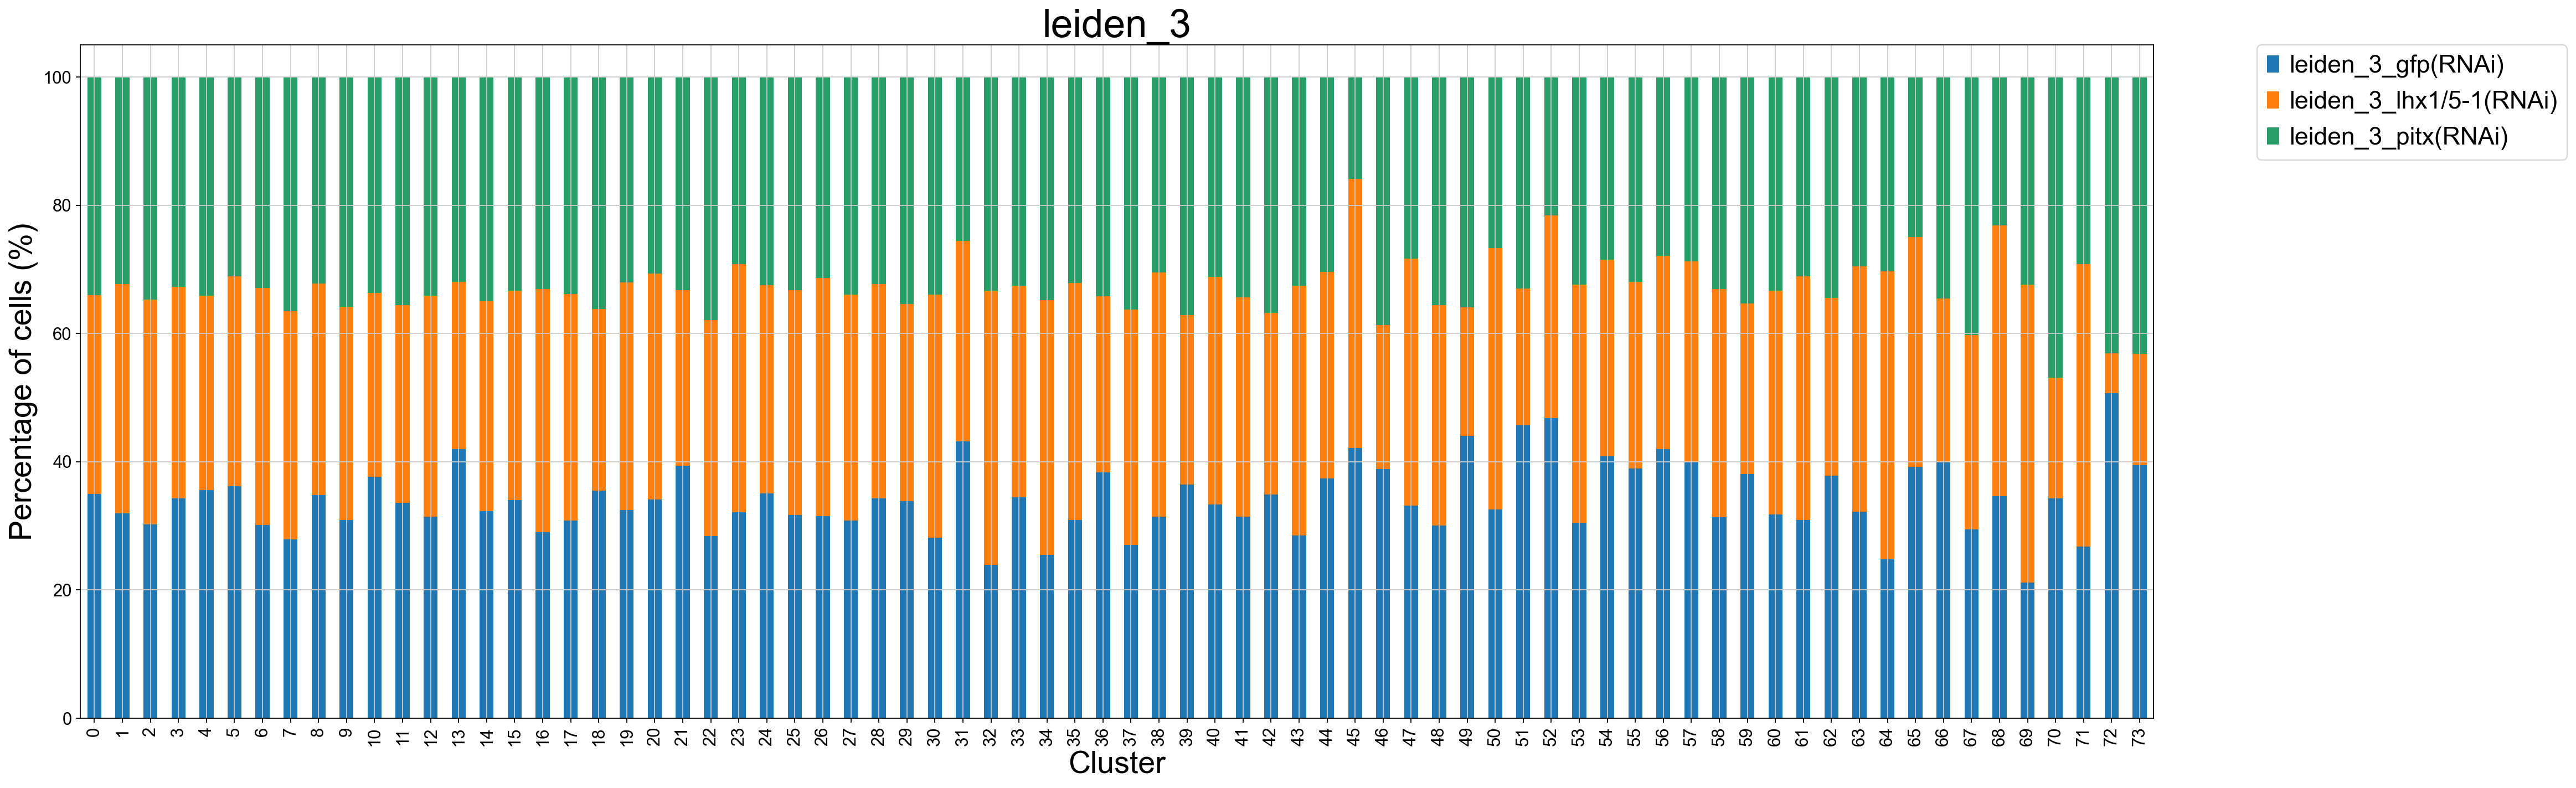

In [36]:
percs_cl=percs_df.apply(lambda x: x*100/sum(x), axis=1)
percs_cl.plot(kind='bar', stacked=True,)
plt.title(clusteringlayer, size=32)
plt.xlabel('Cluster', size=25)
plt.ylabel('Percentage of cells (%)', size=25)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left', borderaxespad=0., fontsize=20)
plt.gcf().set_size_inches(30,10)

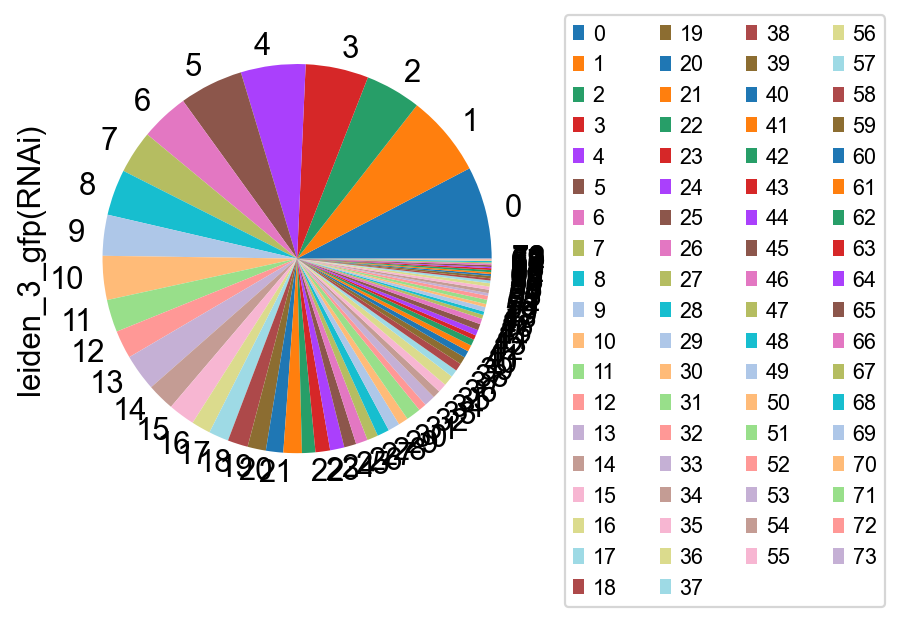

In [37]:
counts_df['leiden_3_gfp(RNAi)'].plot(kind='pie')
plt.legend(ncol=4,bbox_to_anchor=(1.05,1),loc='upper left', borderaxespad=0., fontsize='x-small')

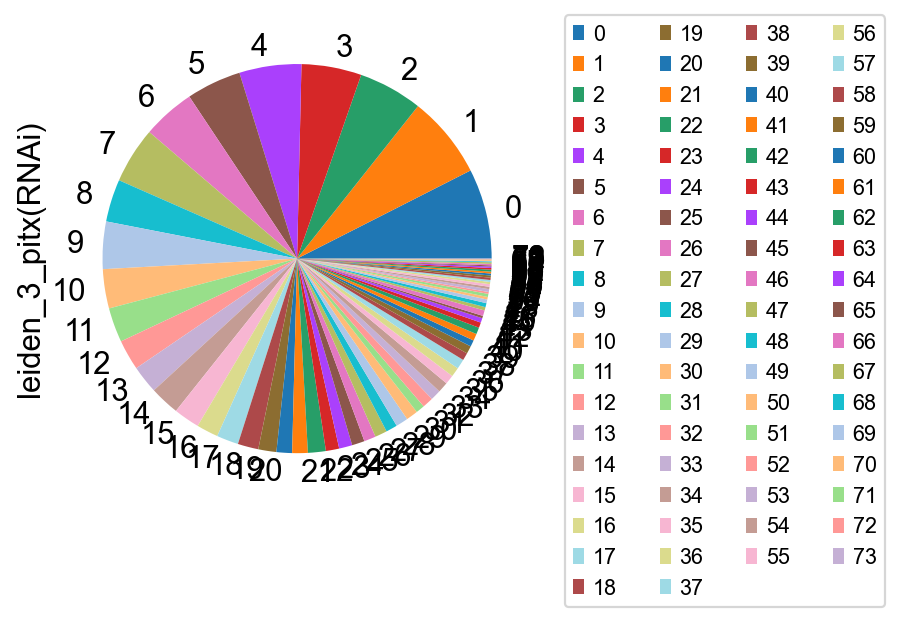

In [38]:
counts_df['leiden_3_pitx(RNAi)'].plot(kind='pie')
plt.legend(ncol=4,bbox_to_anchor=(1.05,1),loc='upper left', borderaxespad=0., fontsize='x-small')

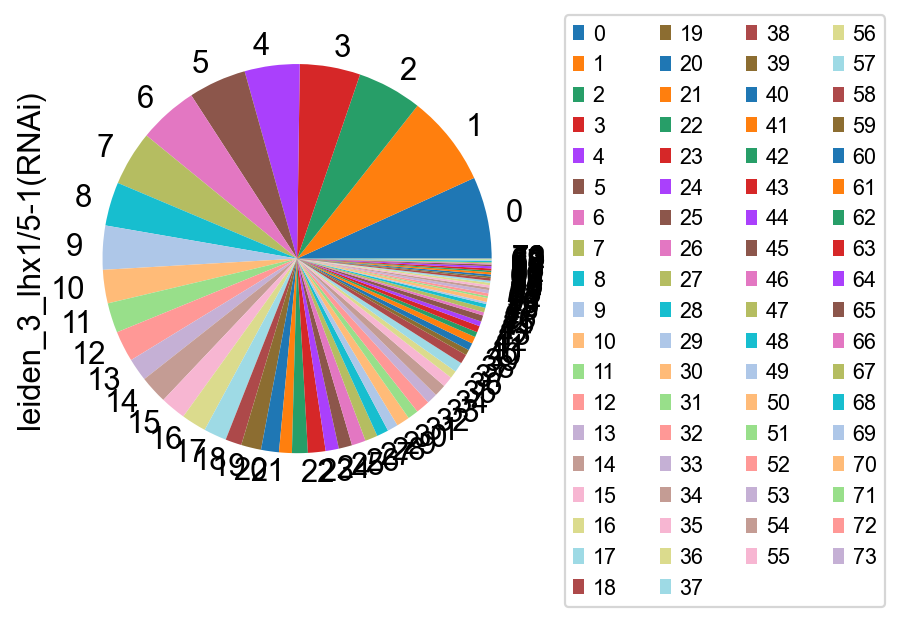

In [39]:
counts_df['leiden_3_lhx1/5-1(RNAi)'].plot(kind='pie')
plt.legend(ncol=4,bbox_to_anchor=(1.05,1),loc='upper left', borderaxespad=0., fontsize='x-small')